# SIMULAZIONE FISICA (STELLE, GAS, GALASSIE)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.interpolate import make_interp_spline
plt.rcParams['agg.path.chunksize'] = 10000
from mpl_toolkits.mplot3d import Axes3D

Leggo e mostro le prime righe del dataset.

In [3]:
dati_stelle = "D:\Master TO\Tirocinio INAF\Simulazioni Aqc4\Datasets\AqC4_124_star.dat"
dati_gas = "D:\Master TO\Tirocinio INAF\Simulazioni Aqc4\Datasets\zoom.vol.snap_le_134_XV_gas.dat"
dati_DarkMatter = "D:\Master TO\Tirocinio INAF\Simulazioni Aqc4\Datasets\zoom.vol.snap_le_134_XV_DM.dat"

df_stelle = pd.read_csv(dati_stelle, delim_whitespace=True, header=None)
df_gas = pd.read_csv(dati_gas, delim_whitespace=True, header=None)
df_dm = pd.read_csv(dati_DarkMatter, delim_whitespace=True, header=None)

df = {0: df_stelle, 1: df_gas, 2: df_dm}

# Rinomino le colonne dei 3 datasets per una migliore lettura.
df_stelle.columns = ['x', 'y', 'z', 'V_x', 'V_y', 'V_z', 'Msun', 'Age', 'Cosmic Time', '[Fe/H]', '[Mg/Fe]', '[O/Fe]', 'Id']
df_gas.columns = ['x', 'y', 'z', 'V_x', 'V_y', 'V_z', 'Msun', 'Id']
df_dm.columns = ['x', 'y', 'z', 'V_x', 'V_y', 'V_z', 'Msun', 'Id']

df_stelle["x"] = df_stelle["x"] * 1e3  # Converti in kpc
df_stelle["y"] = df_stelle["y"] * 1e3  # Converti in kpc
df_stelle["z"] = df_stelle["z"] * 1e3  # Converti in kpc

df_gas["x"] = df_gas["x"] * 1e3  # Converti in kpc
df_gas["y"] = df_gas["y"] * 1e3  # Converti in kpc
df_gas["z"] = df_gas["z"] * 1e3  # Converti in kpc

df_dm["x"] = df_dm["x"] * 1e3  # Converti in kpc
df_dm["y"] = df_dm["y"] * 1e3  # Converti in kpc
df_dm["z"] = df_dm["z"] * 1e3  # Converti in kpc

# mostro le prime righe dei dataframe per controllare che siano stati letti correttamente
print(df_stelle.head())
print(df_gas.head())
print(df_dm.head())

C:\Users\franc\AppData\Local\Temp\ipykernel_2200\646675407.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_stelle = pd.read_csv(dati_stelle, delim_whitespace=True, header=None)


         x        y        z       V_x        V_y       V_z    Msun      Age  \
0  8.37467  2.19100 -4.06002  105.2440    3.10255   12.8153  8381.6  13.0700   
1  8.50702  2.31474 -4.03062  -72.2138  222.70900  -56.6776  8587.8   9.4909   
2  8.31981  2.23250 -3.97941  194.8490  -39.24530  171.3420  8438.1  11.4350   
3  8.47244  2.46221 -3.79390   38.9095  231.10300   65.1261  8553.7   9.0856   
4  8.62270  2.46743 -3.96085  188.7810 -385.97100  -55.9038  8505.4   7.4806   

  Cosmic Time  [Fe/H]  [Mg/Fe]  [O/Fe]            Id  
0     0.51808  -1.651   -0.543  -0.219  1.024999e+09  
1      4.0976  -0.623   -0.393  -0.151  1.021527e+09  
2      2.1534  -1.079   -0.067   0.222  1.017095e+09  
3      4.5029  -0.795   -0.090   0.240  3.163288e+09  
4      6.1078  -1.058   -0.208   0.045  1.020356e+09  
          x         y         z         V_x         V_y         V_z  \
0  9.173878  2.157960 -4.454612  -12.119599  219.289673   73.638679   
1  8.802685  2.466265 -4.463179  -13.115327  15

# Visualizzazione dei dati.

Creo un plot 2D del piano xy con la proiezione delle stelle e del gas in -0.5 < z < 0.5 kpc. Ciò mi permette di notare la forma a spirale e la presenza di qualche braccio.

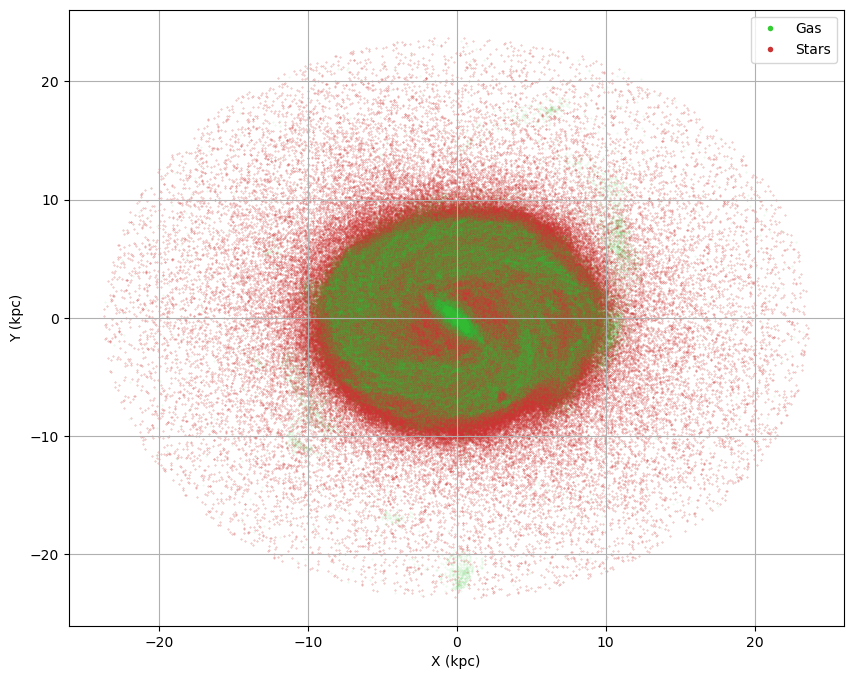

In [22]:
import matplotlib.lines as mlines

# Filter stars and gas for -0.5 < z < 0.5
stars_filtered = df_stelle[(df_stelle['z'] > -0.5) & (df_stelle['z'] < 0.5)]
gas_filtered = df_gas[(df_gas['z'] > -0.5) & (df_gas['z'] < 0.5)]

# Create the plot
plt.figure(figsize=(10, 8))
#definisco i colori per le stelle e il gas
green_base = (0.2, 0.8, 0.2)
red_base = (0.8, 0.2, 0.2)
plt.scatter(stars_filtered['x'], stars_filtered['y'], s=0.1, color=(*red_base, 0.5), label='Stars')
plt.scatter(gas_filtered['x'], gas_filtered['y'], s=0.1, color=(*green_base, 0.15), label='Gas')
plt.xlabel("X (kpc)")
plt.ylabel("Y (kpc)")
#plt.title("Projection on the XY Plane (-0.5 < Z < 0.5 kpc)")
# Customizzo la legenda
green_legend = mlines.Line2D([0], [0], marker='o', color='w', markersize=5, markerfacecolor=green_base)
red_legend = mlines.Line2D([0], [0], marker='o', color='w', markersize=5, markerfacecolor=red_base)

plt.legend(handles=[green_legend, red_legend], labels=["Gas", "Stars"])
#plt.legend(markerscale=20)
plt.grid(True)
plt.show()

Plotto le stelle, il gas e la Dark Matter in tre grafici 3D distinti per visualizzare meglio i dati.

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': '3d'})
fig.suptitle("3D view of the galaxy", fontsize = 16)
#mask = df_stelle["z"]*1000 < 1 and df_stelle["z"] > -1
componenti = {0: "stelle", 1: "gas", 2: "dark matter"}
colore = ["red", "green", "blue"]

for i in componenti.keys():
    axes[i].scatter(df[i]['x'], df[i]['y'], df[i]['z'], s=0.1, c = colore[i], alpha=0.5)
    axes[i].set_title(componenti[i])
    axes[i].set_xlabel("X Position")
    axes[i].set_ylabel("Y Position")
    axes[i].set_zlabel("Z Position")  
    #axes[i].set_title(f"Rotation curve of {componenti[i]}")
    axes[i].grid(True)
    
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

# Rotation curve 

Calcolo la curva di rotazione per i 3 dati, assumendo che le coordinate siano riferite ad un sistema galattocentrico sinistrorso.
Prima però devo calcolare alcuni valori non dati dai dataset.

In [23]:
# calcolo l'angolo phi per ogni dataset
phi_stelle = np.arctan2(df_stelle['y'], df_stelle['x'])
phi_gas = np.arctan2(df_gas['y'], df_gas['x'])
phi_dm = np.arctan2(df_dm['y'], df_dm['x'])

# calcolo la distanza dal centro galattico (raggio)
r_stelle = np.sqrt(df_stelle['x']**2 + df_stelle['y']**2 + df_stelle['z']**2)
r_gas = np.sqrt(df_gas['x']**2 + df_gas['y']**2 + df_gas['z']**2)
r_dm = np.sqrt(df_dm['x']**2 + df_dm['y']**2 + df_dm['z']**2)


# calcolo la velocità di rotazione attorno al centro galattico (vel azimutale)
V_phi_stelle = df_stelle["V_y"] * np.cos(phi_stelle) - df_stelle["V_x"] * np.sin(phi_stelle)
V_phi_gas = df_gas["V_y"] * np.cos(phi_gas) - df_gas["V_x"] * np.sin(phi_gas)
V_phi_dm = df_dm["V_y"] * np.cos(phi_dm) - df_dm["V_x"] * np.sin(phi_dm)

V_phi = {0: V_phi_stelle, 1: V_phi_gas, 2: V_phi_dm}
r = {0: r_stelle, 1: r_gas, 2: r_dm}

Calcolo della rotation curve per i tre datasets.

NameError: name 'colore' is not defined

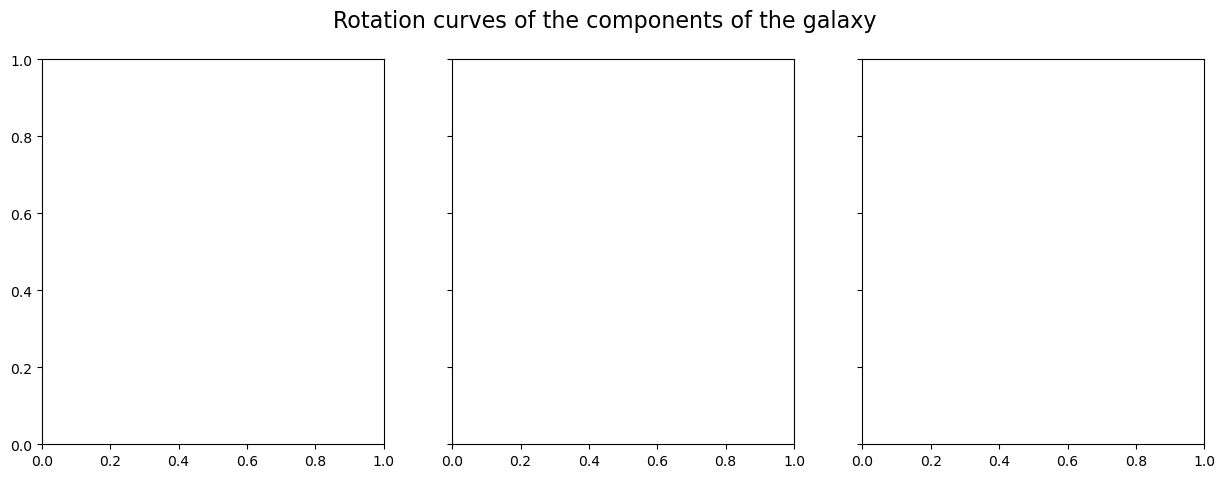

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharey = True)
fig.suptitle("Rotation curves of the components of the galaxy", fontsize = 16)

componenti = {0: "stelle", 1: "gas", 2: "dark matter"}
colore = ["red", "green", "blue"]

for i in componenti.keys():
    axes[i].scatter(r[i], V_phi[i], s = 0.1, c = colore[i], alpha = 0.5)
    axes[i].set_xlabel("Distance from the galactic center")
    axes[i].set_ylabel("V_phi (km/s)")  
    axes[i].set_title(componenti[i])
    axes[i].grid(True)

    avg_V_phi = pd.DataFrame({f'r_{componenti[i]}': r[i], f'V_phi_{componenti[i]}': V_phi[i]}).groupby(f'r_{componenti[i]}')[f'V_phi_{componenti[i]}'].mean()
    unique_r = np.unique(r[i])  # Ottengo i valori unici di r
    coefficients_fit = np.polyfit(unique_r, avg_V_phi, deg=5)  # Fit a quartic polynomial
    poly = np.poly1d(coefficients_fit)
    axes[i].plot(unique_r, poly(unique_r), label="Fit di grado 5", color='black')
    axes[i].legend()

plt.tight_layout()
plt.show()


Proviamo ora a fare lo stesso ma con tutti i dati, per vedere che tipo di andamento ci sarebbe nella galassia.

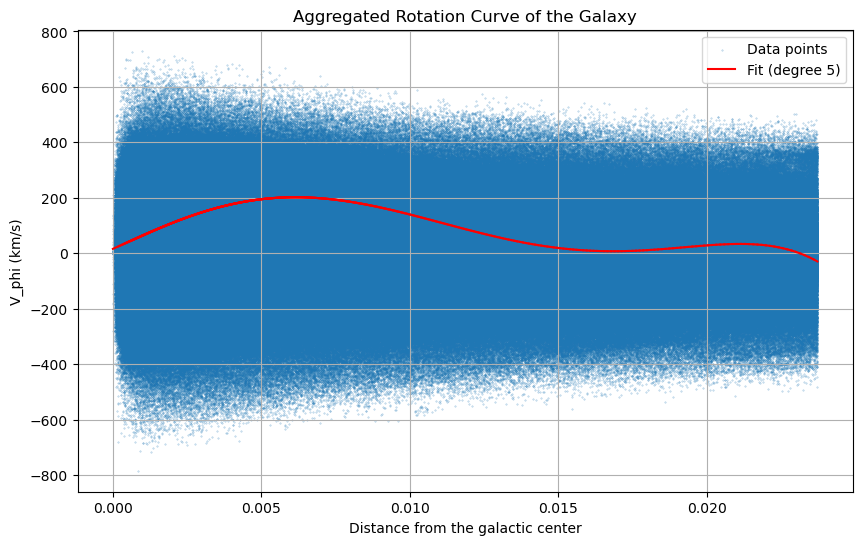

In [10]:
# Combine all r and V_phi values into single arrays
r_combined = np.concatenate([r[0], r[1], r[2]])
V_phi_combined = np.concatenate([V_phi[0], V_phi[1], V_phi[2]])

# Create a DataFrame for easier aggregation
df_combined = pd.DataFrame({'r': r_combined, 'V_phi': V_phi_combined})

# Group by unique radius and calculate the mean velocity
avg_V_phi_combined = df_combined.groupby('r')['V_phi'].mean()

# Extract unique radii and fit a polynomial to the aggregated data
unique_r_combined = np.unique(r_combined)
coefficients_fit_combined = np.polyfit(unique_r_combined, avg_V_phi_combined, deg=5)
poly_combined = np.poly1d(coefficients_fit_combined)

# Plot the aggregated rotation curve
plt.figure(figsize=(10, 6))
plt.scatter(r_combined, V_phi_combined, s=0.1, alpha=0.5, label='Data points')
plt.plot(unique_r_combined, poly_combined(unique_r_combined), color='red', label='Fit (degree 5)')
plt.xlabel("Distance from the galactic center")
plt.ylabel("V_phi (km/s)")
plt.title("Aggregated Rotation Curve of the Galaxy")
plt.legend()
plt.grid(True)
plt.show()

Calcoliamo la massa totale e le velocità teoriche date da $v = \sqrt{\frac{G \cdot M}{r}}$

In [25]:
# Constants
G = 4.30091727e-6  # Gravitational constant in kpc (km/s)^2 / Msun

# Define the range of radii
radii = np.arange(0.1, 20.1, 0.1)  # Avoid division by zero by starting from 0.1

# Combine all data into a single DataFrame
df_all = pd.concat([df_stelle[['x', 'y', 'z', 'Msun']], 
                    df_gas[['x', 'y', 'z', 'Msun']], 
                    df_dm[['x', 'y', 'z', 'Msun']]])

# Calculate the distance of each object from the center
df_all['r'] = np.sqrt(df_all['x']**2 + df_all['y']**2 + df_all['z']**2)

# Initialize an array to store the velocity values
velocities = []

# Calculate the velocity for each radius
for r in radii:
    # Calculate the total mass within the sphere of radius r
    M = df_all[df_all['r'] <= r]['Msun'].sum()
    # Calculate the velocity
    v = np.sqrt(G * M / r)
    velocities.append(v)

In [ ]:
# Filter stars with age < 1 and -0.5 < z < 0.5
young_stars = df_stelle[(df_stelle['Age'] < 1) & (df_stelle["z"] < 0.5) & (df_stelle["z"] > -0.5)]

# Calculate the galactocentric radius and azimuthal velocity for the filtered stars
r_young_stars = np.sqrt(young_stars['x']**2 + young_stars['y']**2 + young_stars['z']**2)
phi_young_stars = np.arctan2(young_stars['y'], young_stars['x'])
V_phi_young_stars = young_stars["V_y"] * np.cos(phi_young_stars) - young_stars["V_x"] * np.sin(phi_young_stars)

# Create a DataFrame for easier aggregation
df_young_stars = pd.DataFrame({'r': r_young_stars, 'V_phi': V_phi_young_stars})

# Group by unique radius and calculate the mean velocity
avg_V_phi_young_stars = df_young_stars.groupby('r')['V_phi'].mean()

# Extract unique radii and fit a polynomial to the aggregated data
unique_r_young_stars = np.unique(r_young_stars)
coefficients_fit_young_stars = np.polyfit(unique_r_young_stars, avg_V_phi_young_stars, deg=5)
poly_young_stars = np.poly1d(coefficients_fit_young_stars)

Confrontiamo la curva teorica (data dalla velocità $v = \sqrt{\frac{G \cdot M}{r}}$) con il fit relativo ai dati da stelle

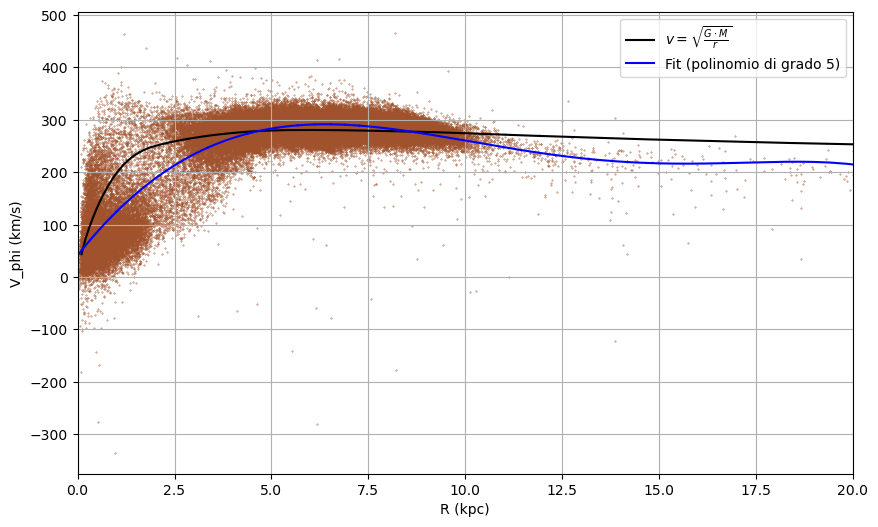

In [9]:
# Plot the rotation curve for young stars
plt.figure(figsize=(10, 6))
plt.scatter(r_young_stars, V_phi_young_stars, s=0.1, alpha=1, c = "sienna")
plt.plot(radii, velocities, label=r'$v = \sqrt{\frac{G \cdot M}{r}}$', color='black')
plt.plot(unique_r_young_stars, poly_young_stars(unique_r_young_stars), color='blue', label='Fit (polinomio di grado 5)')
plt.xlabel("R (kpc)")
plt.ylabel("V_phi (km/s)")
plt.xlim(0, 20)
#plt.title("Theoretical and simulated Rotation Curve of Stars with Age < 1 Gyr and -0.5 < z < 0.5 kpc")
plt.legend()
plt.grid(True)
plt.show()

e dal gas

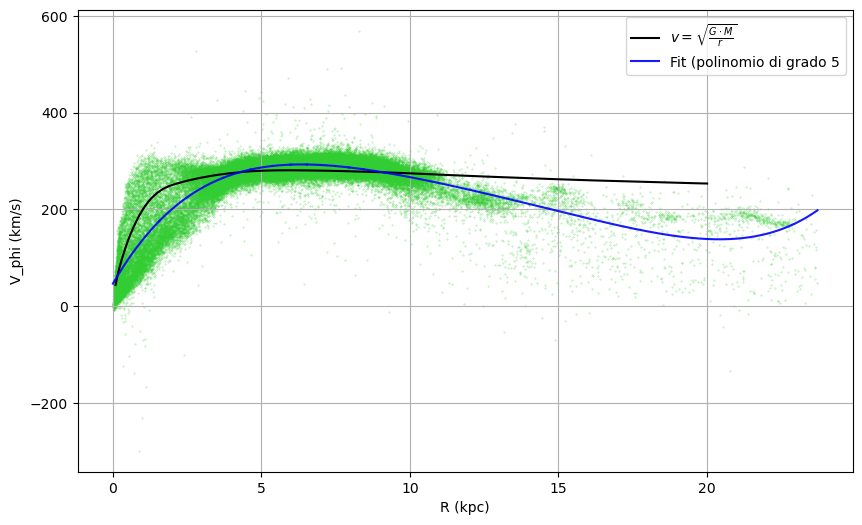

In [27]:
componenti = {0: "stelle", 1: "gas", 2: "dark matter"}
plt.figure(figsize=(10, 6))

# Filter gas with -0.5 < z < 0.5
gas_filtered = df_gas[(df_gas['z'] > -0.5) & (df_gas['z'] < 0.5)]

# Calculate the galactocentric radius and azimuthal velocity for the filtered gas
r_gas_filtered = np.sqrt(gas_filtered['x']**2 + gas_filtered['y']**2 + gas_filtered['z']**2)
phi_gas_filtered = np.arctan2(gas_filtered['y'], gas_filtered['x'])
V_phi_gas_filtered = gas_filtered["V_y"] * np.cos(phi_gas_filtered) - gas_filtered["V_x"] * np.sin(phi_gas_filtered)

plt.scatter(r_gas_filtered, V_phi_gas_filtered, s = 0.1, c = "limegreen", alpha = 0.5) #1) scatter plot di tutti i punti del gas

plt.plot(radii, velocities, label=r'$v = \sqrt{\frac{G \cdot M}{r}}$', color='black') #2) fit teorico della curva di rotazione

avg_V_phi_gas = pd.DataFrame({f'r_{componenti[1]}': r_gas_filtered, f'V_phi_{componenti[1]}': V_phi_gas_filtered}).groupby(f'r_{componenti[1]}')[f'V_phi_{componenti[1]}'].mean()
unique_r_gas = np.unique(r_gas_filtered)  # Ottengo i valori unici di r
coefficients_fit_gas = np.polyfit(unique_r_gas, avg_V_phi_gas, deg=5)  # Fit a quintic polynomial
polyfit_gas = np.poly1d(coefficients_fit_gas)
plt.plot(unique_r_gas, polyfit_gas(unique_r_gas), label="Fit (polinomio di grado 5", color='blue', alpha = 0.9) #3) fit del gas

plt.xlabel("R (kpc)")
plt.ylabel("V_phi (km/s)")
#plt.title("Theoretical and simulated Rotation Curve of the gas")
plt.legend()
plt.grid(True)
plt.show()

E infine per la dark matter.

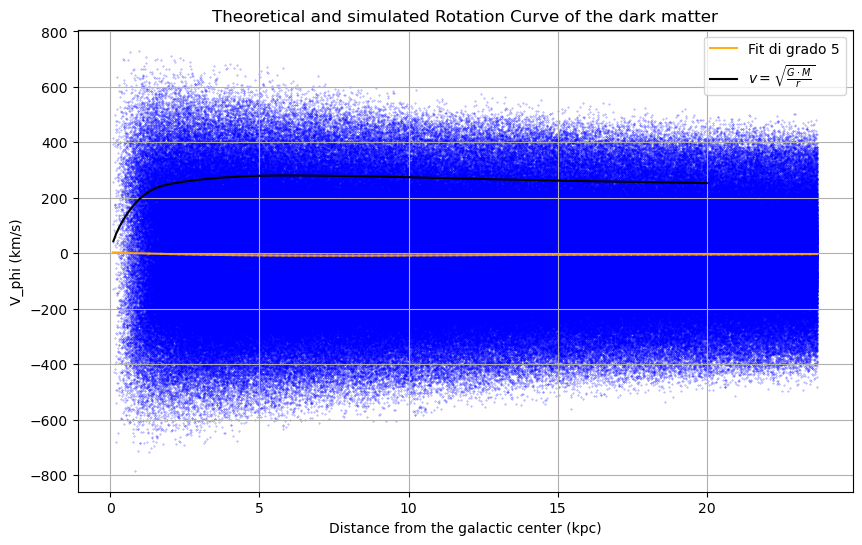

In [12]:
componenti = {0: "stelle", 1: "gas", 2: "dark matter"}
colore = ["red", "green", "blue"]

plt.figure(figsize=(10, 6))

plt.scatter(r_dm, V_phi_dm, s = 0.1, c = colore[2], alpha = 0.5) #1) scatter plot di tutti i punti della Dark Matter

avg_V_phi_dm = pd.DataFrame({f'r_{componenti[2]}': r_dm, f'V_phi_{componenti[2]}': V_phi_dm}).groupby(f'r_{componenti[2]}')[f'V_phi_{componenti[2]}'].mean()
unique_r_dm = np.unique(r_dm)  # Ottengo i valori unici di r
coefficients_fit_dm = np.polyfit(unique_r_dm, avg_V_phi_dm, deg=5)  # Fit a quintic polynomial
polyfit_dm = np.poly1d(coefficients_fit_dm)
plt.plot(unique_r_dm, polyfit_dm(unique_r_dm), label="Fit di grado 5", color='orange', alpha = 0.9) #2) fit della dark matter

plt.plot(radii, velocities, label=r'$v = \sqrt{\frac{G \cdot M}{r}}$', color='black') #3) fit teorico della curva di rotazione
plt.xlabel("Distance from the galactic center (kpc)")
plt.ylabel("V_phi (km/s)")
plt.title("Theoretical and simulated Rotation Curve of the dark matter")
plt.legend()
plt.grid(True)
plt.show()

# Plot comprendenti età e metallicità

Plottiamo ora la distribuzione delle stelle dal centro galattico in base alla loro età e al valore di [Fe/H], suddividendole nelle fascie [mld di anni]:
- [0, 10] generalmente associate al thin disk
- 11 generalmente associate al thick disk
- 14 generalmente associate all'halo

Verrà fatto poi un simile plot per la metallicità (più una stella è giovane, più è ricca di metalli)

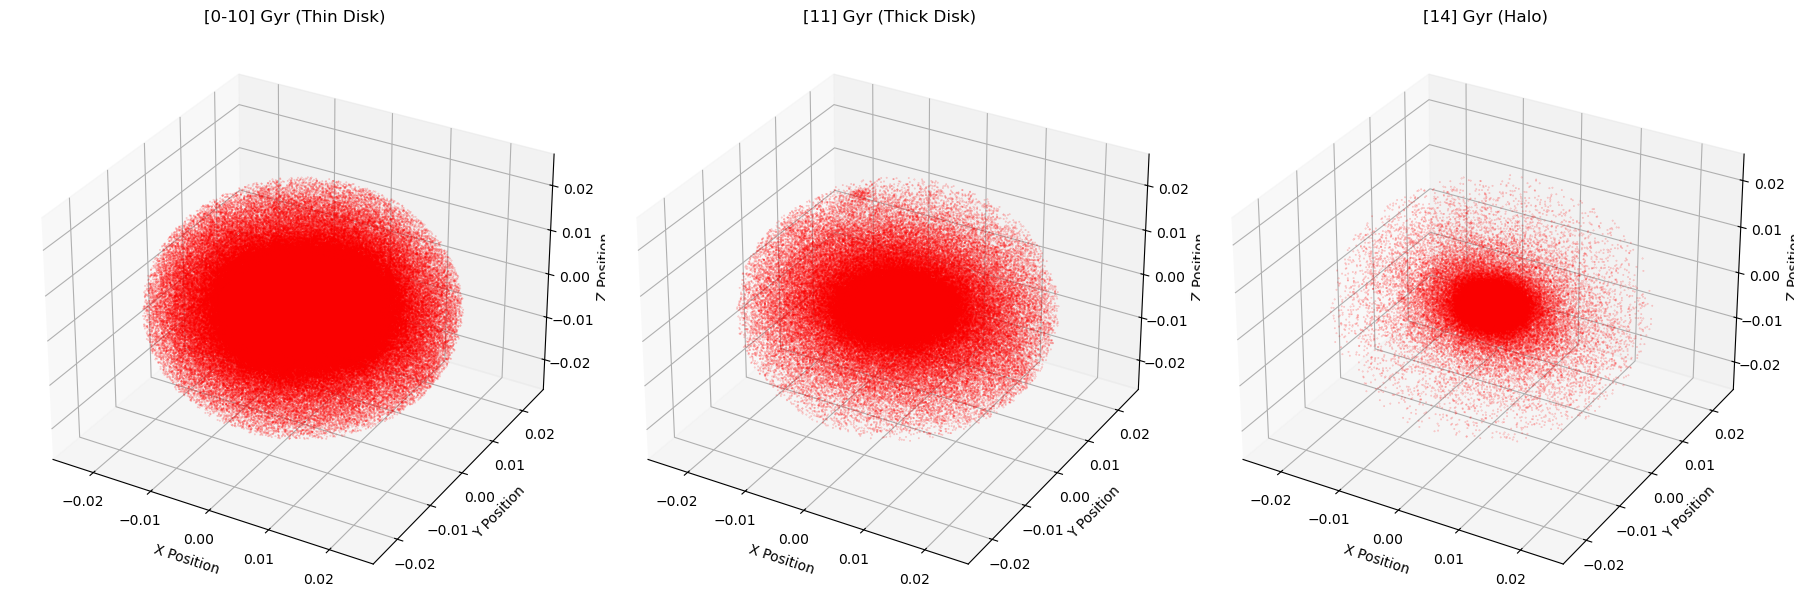

In [11]:
# Define the age groups
age_bins = [(0, 10), (10.5, 11.5), (13, 14)]
age_labels = ["[0-10] Gyr (Thin Disk)", "[11] Gyr (Thick Disk)", "[14] Gyr (Halo)"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': '3d'})

# Loop through each age group and create a scatter plot
for i, (age_range, label) in enumerate(zip(age_bins, age_labels)):
    mask = (df_stelle['Age'] >= age_range[0]) & (df_stelle['Age'] < age_range[1])
    df_group = df_stelle[mask]
    
    axes[i].scatter(df_group['x'], df_group['y'], df_group['z'], s=0.1, c = "red", alpha=0.3)
    axes[i].set_title(f"{label}")
    axes[i].set_xlabel("X Position")
    axes[i].set_ylabel("Y Position")
    axes[i].set_zlabel("Z Position")

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

C:\Users\franc\AppData\Local\Temp\ipykernel_12028\555717198.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
c:\Users\franc\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


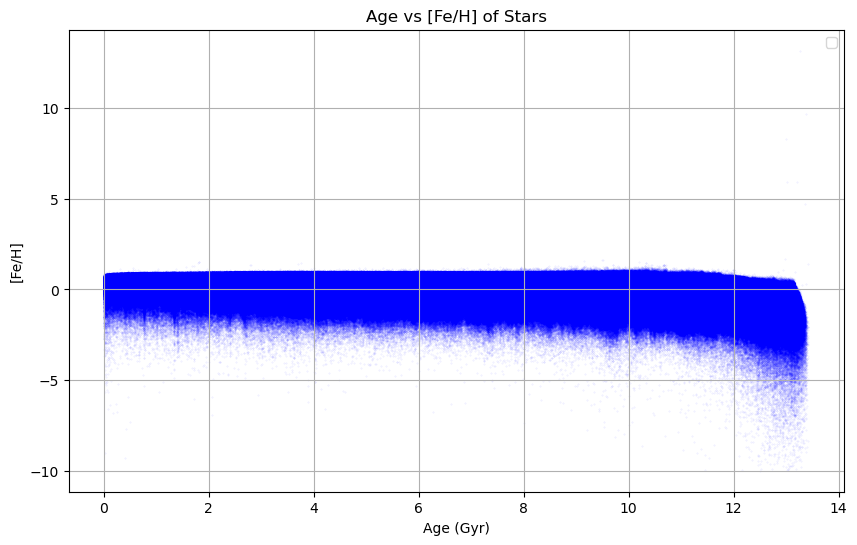

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_stelle['Age'], df_stelle['[Fe/H]'], s=0.1, alpha=0.1, color='blue')
#plt.plot(unique_age, poly_combined(unique_age), color='red', linewidth = 2, label='Fit (degree 5)')
plt.xlabel("Age (Gyr)")
plt.ylabel("[Fe/H]")
plt.title("Age vs [Fe/H] of Stars")
plt.legend()
plt.grid(True)
plt.show()

Come previsto, al crescere dell'età corrisponde generalmente un'abbassamento della metallicità.